# 2-2 퍼셉트론으로 동작하는 딥러닝 모델

본 노트북은 본문 2-2 절의 코드 예제([코드 2-1] ~ [코드 2-6])를 절 흐름 그대로 모은 것이다. 텐서와 자동 미분만으로 AND 게이트 시뮬레이터 퍼셉트론 모델을 정의하고, 직접 만든 손실 함수·최적화 함수·학습 함수로 학습한 뒤, 학습 전후의 결정 경계를 시각화한다.

In [1]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

## 라이브러리 import 와 시드 고정

본 절의 예제에 필요한 라이브러리를 import 하고 시드를 고정한다.

In [2]:
# 참고 - 라이브러리 import 와 시드 고정
import random

import numpy as np
import torch

SEED = 2
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## AND 게이트 시뮬레이터의 학습 데이터

두 입력의 논리곱(AND)을 모사하는 4개 샘플을 입력 `X` 와 정답 `Y_true` 텐서로 준비한다. 이 4개 샘플 전부를 훈련 데이터로 사용하며, 별도의 평가용 데이터는 두지 않는다.

In [ ]:
# 코드 2-1 - AND 게이트 시뮬레이터의 학습 데이터

X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
Y_true = torch.tensor([[0.], [0.], [0.], [1.]])

# 파이썬 리스트와 마찬가지로 len() 함수로 최상위 차원의 크기를 구할 수 있음
print(f'데이터 샘플의 개수: {len(X)}')      

데이터 샘플의 개수: 4


## 퍼셉트론 파라미터 정의

두 입력에 대응하는 가중치 `weights`((2, 1) 형태)와 하나의 편향 `bias`((1, ) 형태)를 표준 정규 분포 난수로 초기화한다. 두 텐서 모두 학습 대상이므로 `requires_grad=True` 로 만든다.

In [ ]:
# 코드 2-2 - 모델의 학습 파라미터

# 퍼셉트론 모델의 파라미터 정의
weights = torch.randn((2, 1), requires_grad=True)   # 가중치: (2, 1) 형태
bias = torch.randn((1, ), requires_grad=True)       # 편향: (1, ) 형태


In [5]:

print('파라미터의 초기값')
print(f'  가중치: {weights[0].item():.2f}, {weights[1].item():.2f}')
print(f'  편향: {bias.item():.2f}')

파라미터의 초기값
  가중치: 0.39, -0.22
  편향: -0.32


## 퍼셉트론 모델 함수

퍼셉트론의 출력은 입력의 가중합에 편향을 더한 뒤 시그모이드 활성화 함수를 거쳐 계산한다. 가중합은 행렬 곱(`@` 연산자)으로 한 번에 구하고, (4, 1) 가중합에 (1, ) 편향을 더할 때는 브로드캐스팅이 적용된다.

In [ ]:
# 코드 2-3 - 시그모이드 활성화 함수와 퍼셉트론 모델 함수

# 시그모이드 활성화 함수
def sigmoid(z):
    # torch.exp() 함수: 자연상수 e의 지수를 계산하는 지수 함수
    return 1 / (1 + torch.exp(-z))

# 퍼셉트론 모델 함수
def model(X, weights, bias):
    # 가중합 계산: 텐서 간의 행렬 곱 연산에 @ 연산자 사용
    weighted_sum = X @ weights      # (4, 2) @ (2, 1) -> (4, 1)
    # 편향 추가
    Z = weighted_sum + bias         # (4, 1) + (1, ) -> (4, 1) (브로드캐스팅)
    Y_pred = sigmoid(Z)             # 시그모이드 활성화 함수
    return Y_pred

## 손실 함수와 최적화 함수

손실은 평균 제곱 오차로 계산한다. 최적화 함수는 `no_grad()` 컨텍스트 안에서 각 파라미터의 기울기(`grad`)에 학습률을 곱한 값만큼 제자리 연산(`-=`)으로 차감한다. 텐서는 가변형 객체이므로 함수 안에서 값을 바꾸면 반환값 없이도 변경이 유지된다.

In [ ]:
# 코드 2-4 - 손실 함수와 최적화 함수

# 평균 제곱 오차 손실 함수
def criterion(Y_pred, Y_true):
    return ((Y_pred - Y_true) ** 2).mean()

# 기울기로 파라미터를 조절하는 최적화 함수
def optimizer(weights, bias, learning_rate):
    with torch.no_grad():                           # with 블록: 연산 그래프에 기록하지 않음
        weights -= learning_rate * weights.grad     # 가중치 파라미터의 최적화
        bias -= learning_rate * bias.grad           # 편향 파라미터의 최적화

## 학습 함수

순전파 → 손실 계산 → 역전파 → 파라미터 최적화 → 기울기 초기화를 `epochs` 회 반복한다. 기울기 초기화(`zero_()`)는 역전파로 기울기를 계산한 뒤, 파라미터 최적화 다음에 호출해야 한다.

In [ ]:
# 코드 2-5 - 퍼셉트론 모델의 학습 루프 함수

# 퍼셉트론 모델을 학습하는 학습 함수
def train(model, X, Y_true, weights, bias, criterion, optimizer, epochs, learning_rate):
    # 학습 로그는 공통 표준인 common.EpochLogger를 사용해 저장하고 출력
    # 사용법은 교재 추가 설명 및 공통 라이브러리 API 문서 참조

    # 학습 로그 객체 생성 및 초기화
    log = common.EpochLogger(
        epochs,
        columns=('손실', 'w1', 'w2', 'b'),
        formats=('{:.4f}', '{:.2f}', '{:.2f}', '{:.2f}'),
        minimize='손실',
    )

    for epoch in range(epochs):
        Y_pred = model(X, weights, bias)            # 순전파
        loss = criterion(Y_pred, Y_true)            # 손실 계산
        loss.backward()                             # 역전파 (기울기 계산)
        optimizer(weights, bias, learning_rate)     # 파라미터 최적화
        weights.grad.zero_()                        # 가중치 파라미터 기울기 초기화
        bias.grad.zero_()                           # 편향 파라미터 기울기 초기화

        # 에포크별 손실과 파라미터(w1, w2, b)를 표준 학습 로거에 저장
        with torch.no_grad():
            log.row(
                epoch + 1, loss.item(),
                weights[0].item(), weights[1].item(), bias.item(),
            )
    return log

## 모델 학습

학습 전 결정 경계를 그릴 수 있도록 초기 파라미터를 백업해 둔 뒤, 학습률 `LR` 0.1, 전체 학습 에포크 `EPOCHS` 1000 으로 모델을 학습한다.

In [9]:
# 참고 - 학습 전 결정 경계 시각화용 파라미터 백업
with torch.no_grad():
    initial_w1 = weights[0].item()
    initial_w2 = weights[1].item()
    initial_bias = bias.item()

In [ ]:
# 코드 2-6 - AND 게이트 모델의 학습

# 하이퍼파라미터 설정
LR = 0.1                    # 학습률
EPOCHS = 1000               # 전체 학습 에포크

# 파라미터 초깃값
print(f'학습 전 파라미터: ({weights[0].item():.2f},',
      f'{weights[1].item():.2f}, {bias.item():.2f})')

# 모델을 학습하고 표준 학습 로거 객체 반환
log = train(
    model, X, Y_true, weights, bias, criterion, optimizer,
    EPOCHS, LR,
)

# 학습 로그 출력
log.summary()


학습 전 파라미터: (0.39, -0.22, -0.32)
    epoch         손실           w1           w2            b     시간
   1/1000       0.2174         0.39        -0.22        -0.33     0:00
 100/1000       0.1659         0.54         0.11        -0.92     0:00
 200/1000       0.1371         0.75         0.46        -1.27     0:00
 300/1000       0.1168         0.94         0.74        -1.56     0:00
 400/1000       0.1019         1.11         0.98        -1.81     0:00
 500/1000       0.0905         1.27         1.17        -2.04     0:00
 600/1000       0.0814         1.41         1.34        -2.25     0:00
 700/1000       0.0739         1.53         1.48        -2.44     0:00
 800/1000       0.0676         1.65         1.62        -2.62     0:00
 900/1000       0.0623         1.76         1.74        -2.79     0:00
1000/1000       0.0576         1.86         1.85        -2.94     0:00
----------------------------------------------------------------------
최적 1000 에포크 · 손실 0.0576 · 전체 학습 시간 0:00


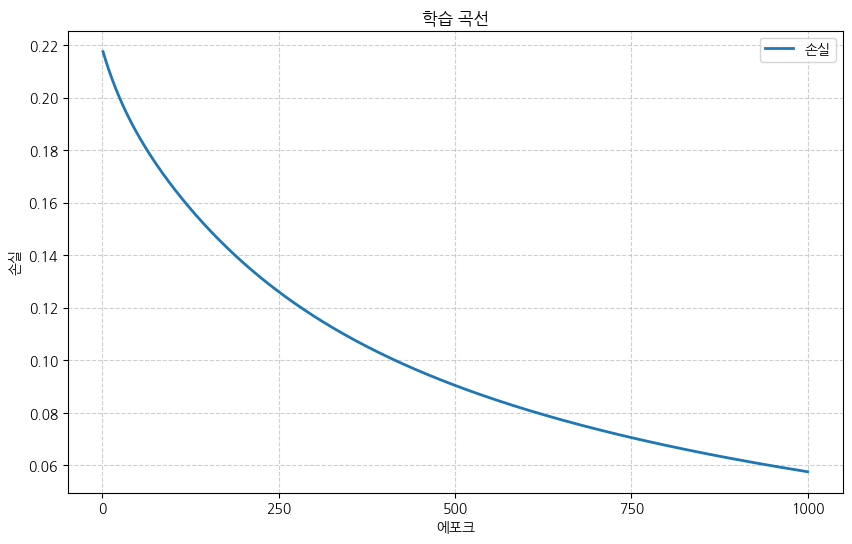

In [11]:
# 참고 - 학습 곡선 시각화
log.plot(title='학습 곡선')

에포크가 진행될수록 손실이 작아지고, 두 가중치는 양수로, 편향은 음수로 커지는 방향으로 수렴한다. 가중치가 양수로 커지면서 두 입력 모두 1 일 때만 가중합이 충분히 커져 1 을 출력하도록 학습된다.

## 결과 확인과 시각화 ([그림 2-6] 대응)

결정 경계는 $x_1 w_1 + x_2 w_2 + b = 0$, 즉 기울기 $-w_1/w_2$, $x_2$ 절편 $-b/w_2$ 인 직선이다. 학습 전과 후의 파라미터로 각각 결정 경계를 그려 비교한다.

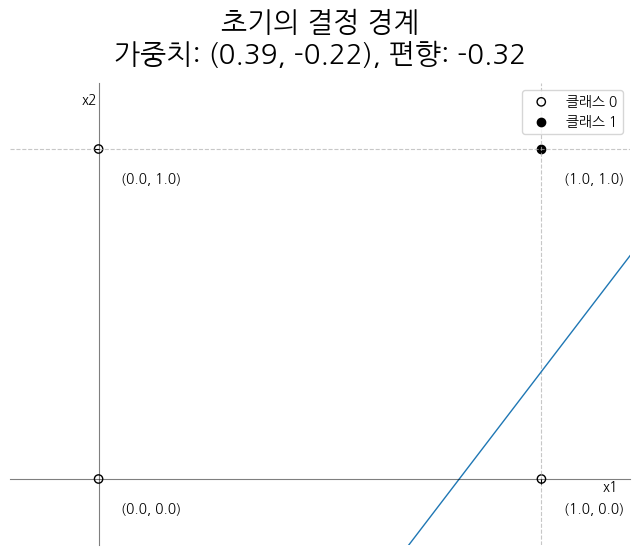

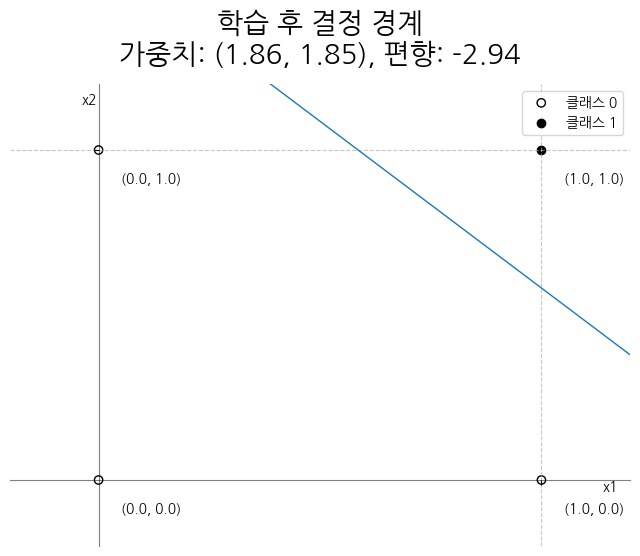

In [12]:
# 참고 - 학습 전/후 결정 경계 비교 ([그림 2-6] 대응)
# AND 게이트 샘플 (x1, x2, y)
sample = (
    [0., 1., 0., 1.],   # x1
    [0., 0., 1., 1.],   # x2
    [0,  0,  0,  1 ],   # y
)

with torch.no_grad():
    final_w1 = weights[0].item()
    final_w2 = weights[1].item()
    final_bias = bias.item()

viz.plot_decision_boundary(
    sample=sample,
    params=[
        (initial_w1, initial_w2, initial_bias),   # 학습 전        
    ],
    title=f'초기의 결정 경계\n가중치: ({initial_w1:.2f}, {initial_w2:.2f}), 편향: {initial_bias:.2f}',
    x_label='x1', y_label='x2',
    x_lim=(-0.2, 1.2), y_lim=(-0.2, 1.2)

)

viz.plot_decision_boundary(
    sample=sample,
    params=[        
        (final_w1, final_w2, final_bias),         # 학습 후
    ],    
    title=f'학습 후 결정 경계\n가중치: ({final_w1:.2f}, {final_w2:.2f}), 편향: {final_bias:.2f}',
    x_label='x1', y_label='x2',
    x_lim=(-0.2, 1.2), y_lim=(-0.2, 1.2)
)

학습 후의 결정 경계는 $(1, 1)$ 만 한쪽에 두고 나머지 세 점을 반대편에 두는 위치로 이동했다. 다음 절(2-3)에서는 같은 모델을 파이토치 고수준 API(`nn.Module`, `nn.MSELoss`, `optim.SGD`)로 다시 구현한다.

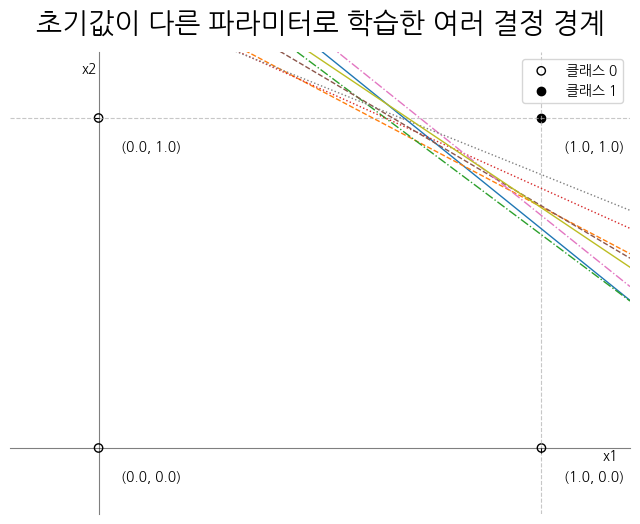

In [13]:
# 참고 - 9가지 초기 파라미터로 학습한 결정 경계 ([그림 2-7] 대응)
# 무작위 초깃값을 바꿔 9번 학습한 뒤, 각 학습의 결정 경계를 한 그림에 겹쳐 그린다.
torch.manual_seed(SEED)             # 9개 초깃값을 재현 가능하게 고정
boundaries = []
for _ in range(9):
    # 매 시도마다 다른 무작위 초깃값으로 파라미터 생성
    weights = torch.randn((2, 1), requires_grad=True)
    bias = torch.randn((1, ), requires_grad=True)
    # 로그 없이 조용히 학습 (학습 루프만 EPOCHS회 반복)
    for epoch in range(500):
        Y_pred = model(X, weights, bias)            # 순전파
        loss = criterion(Y_pred, Y_true)            # 손실 계산
        loss.backward()                             # 역전파
        optimizer(weights, bias, LR)                # 파라미터 최적화
        weights.grad.zero_()                        # 가중치 기울기 초기화
        bias.grad.zero_()                           # 편향 기울기 초기화
    with torch.no_grad():
        boundaries.append(
            (weights[0].item(), weights[1].item(), bias.item())
        )

# AND 게이트 샘플 (x1, x2, y)
sample = (
    [0., 1., 0., 1.],   # x1
    [0., 0., 1., 1.],   # x2
    [0,  0,  0,  1 ],   # y
)
viz.plot_decision_boundary(
    sample=sample,
    params=boundaries,
    title='초기값이 다른 파라미터로 학습한 여러 결정 경계',
    x_label='x1', y_label='x2',
    x_lim=(-0.2, 1.2), y_lim=(-0.2, 1.2)
)